In [1]:
import os
import pandas as pd
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
from datetime import datetime
import seaborn as sns
import math
import glob
import re
sns.set(style='whitegrid')

In [2]:
wid_exp = [(512, 4, 220), (1024, 4, 350), (2048, 4, 500), (512, 8, 350), (768, 8, 500), (1024, 8, 500), (512, 16, 650), (1024, 12, 650),(2560, 4, 1), (2560, 8, 1), (2560, 16, 1)]
lrs = [0.0005, 0.001, 0.002, 0.004, 0.008, 0.016, 0.032, 0.064]
seeds = [1]
depth = 14

time = '20251001_063034'

In [3]:
results_val = {}
results_tr = {}
for lr in lrs:
    for width, num_exp, _ in wid_exp:
            num_act = int(num_exp // 4)
            for seed in seeds:
                print()
                file_name = f'../run_data/mutransfer_lr_cccc/out_{time}/width{width}_depth{depth}_experts{num_exp}_active{num_act}_seed{seed}_lr{lr}/log.csv'
                if os.path.exists(file_name):
                    try:
                        csv_df = pd.read_csv(file_name)
                    except:
                        print(f"File {file_name} is corrupted, skipping")
                        results_val[(width, num_exp, num_act, seed, lr)] = 10.0
                        results_tr[(width, num_exp, num_act, seed, lr)] = 10.0
                        continue
                    val_loss = csv_df.iloc[-1]['val/loss']
                    if val_loss > 0.0:
                        avg_train_loss = np.mean(csv_df['train/loss'][-50:])
                        print(f"result found for {file_name}, val_loss achieved {val_loss}")
                        print(f"average training loss for last 50 steps: {avg_train_loss}")
                        results_val[(width, num_exp, num_act, seed, lr)] = val_loss
                        results_tr[(width, num_exp, num_act, seed, lr)] = avg_train_loss
                    else:
                        print(f"No validation loss found for {file_name}, trial ended at iteration {csv_df.shape[0]}")
                        print(f"Lowest traininig loss achieved: {np.min(csv_df['train/loss'])}")
                else:
                    print(f"File {file_name} does not exist, check your path")


result found for ../run_data/mutransfer_lr_cccc/out_20251001_063034/width512_depth14_experts4_active1_seed1_lr0.0005/log.csv, val_loss achieved 5.397987365722656
average training loss for last 50 steps: 5.391171932220459

result found for ../run_data/mutransfer_lr_cccc/out_20251001_063034/width1024_depth14_experts4_active1_seed1_lr0.0005/log.csv, val_loss achieved 5.358705997467041
average training loss for last 50 steps: 5.360886573791504

result found for ../run_data/mutransfer_lr_cccc/out_20251001_063034/width2048_depth14_experts4_active1_seed1_lr0.0005/log.csv, val_loss achieved 5.15606164932251
average training loss for last 50 steps: 5.159681797027588

result found for ../run_data/mutransfer_lr_cccc/out_20251001_063034/width512_depth14_experts8_active2_seed1_lr0.0005/log.csv, val_loss achieved 5.391741752624512
average training loss for last 50 steps: 5.393105983734131

result found for ../run_data/mutransfer_lr_cccc/out_20251001_063034/width768_depth14_experts8_active2_seed1_lr

In [4]:
def plot_results(result, title = ""):
    plt.figure(figsize=(10, 6))
    config_results = {}
    for (width, num_exp, num_act, seed, lr), mse in result.items():
        config = (num_exp, width)
        if config not in config_results:
            config_results[config] = []
        config_results[config].append((lr, mse))
    
    # Average over seeds for each configuration and lr
    averaged_results = {}
    for config, pts in config_results.items():
        lr_to_mses = {}
        for lr, mse in pts:
            if lr not in lr_to_mses:
                lr_to_mses[lr] = []
            lr_to_mses[lr].append(mse)
        
        # Average MSEs for each lr
        averaged_pts = []
        for lr in sorted(lr_to_mses.keys()):
            avg_mse = np.mean(lr_to_mses[lr])
            averaged_pts.append((lr, avg_mse))
        averaged_results[config] = averaged_pts
    
    # Count total experiments
    total_experiments = len(result)
    print(f"Total experiments: {total_experiments}")
    
    # Print summary
    print("\nResults by configuration:")
    for (n_exp, width), pts in sorted(averaged_results.items()):
        valid_pts = [(lr, mse) for lr, mse in pts if not math.isnan(mse)]
        print(f"  n={n_exp}, width={width}: {len(valid_pts)} valid lr points")
        if valid_pts:
            best_lr, best_mse = min(valid_pts, key=lambda x: x[1])
            print(f"    Best: lr={best_lr:.3e}, MSE={best_mse:.6f}")
    
    # Plot each configuration
    colors = plt.cm.tab10(np.linspace(0, 1, 10))
    markers = ['o', 's', '^', 'v', 'D', 'p', '*', 'h']
    
    for idx, ((n_exp, width), pts) in enumerate(sorted(averaged_results.items())):
        if pts:
            # Sort by lr for proper line plotting
            pts_sorted = sorted(pts, key=lambda t: t[0])
            lrs_plot, mses = zip(*pts_sorted)
            
            # Filter out NaN values
            valid_pts = [(lr, mse) for lr, mse in zip(lrs_plot, mses) if not math.isnan(mse)]
            
            if valid_pts:
                valid_lrs, valid_mses = zip(*valid_pts)
                color = colors[idx % len(colors)]
                marker = markers[idx % len(markers)]
                num_act = int(n_exp // 4)
                plt.plot(valid_lrs, valid_mses, marker=marker, color=color,
                        label=f'n_exp={n_exp}, n_act={num_act}, width={width}', linewidth=1.5, markersize=6,
                        alpha=0.8)
                
                # Mark the best point with a star
                best_idx = np.argmin(valid_mses)
                plt.scatter(valid_lrs[best_idx], valid_mses[best_idx], 
                           s=200, color=color, marker='*', edgecolor='black', 
                           linewidth=2, zorder=10)

    plt.xscale('log', base=2)
    plt.yscale('log')
    plt.ylim(3.0, 10.0)
    plt.xlabel(r'Learning rate', fontsize=12)
    plt.ylabel('log perplexity', fontsize=12)
    plt.title(f'Hyperparameter Transfer Results ' + title, 
              fontsize=14)
    plt.legend(fontsize=10, loc='best', ncol=2)
    plt.grid(True, alpha=0.3, which='both')
    plt.tight_layout()
    
    # Save plot
    plot_dir = "plots"
    os.makedirs(plot_dir, exist_ok=True)
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    plot_name = os.path.join(plot_dir, f"hp_transfer_plot_{timestamp}.png")
    plt.savefig(plot_name, dpi=150, bbox_inches='tight')
    print(f"\nPlot saved as: {plot_name}")
    
    plt.show()
    
    return averaged_results



def find_job_file(base_path, time_dir, job_prefix):

    # Construct the search path
    search_pattern = os.path.join(base_path, time_dir, "stdout", f"{job_prefix}_*.log")

    # Find matching files
    matches = glob.glob(search_pattern)

    if not matches:
        return None, None

    # Take the first match if multiple exist
    full_path = matches[0]
    filename = os.path.basename(full_path)

    # Parse filename: job_0008_gpu7_w256_exp4_lr4.52e-02_seed0.log
    pattern = r'job_\d+_gpu\d+_w(\d+)_exp(\d+)_lr([\d.e\-+]+)_seed(\d+)\.log'
    match = re.match(pattern, filename)

    if not match:
        return filename, None

    params = {
        'width': int(match.group(1)),
        'num_exp': int(match.group(2)),
        'lr': float(match.group(3)),
        'seed': int(match.group(4))
    }

    return filename, params

Total experiments: 80

Results by configuration:
  n=4, width=512: 8 valid lr points
    Best: lr=3.200e-02, MSE=4.299799
  n=4, width=1024: 8 valid lr points
    Best: lr=1.600e-02, MSE=4.119670
  n=4, width=2048: 8 valid lr points
    Best: lr=3.200e-02, MSE=3.937549
  n=4, width=2560: 8 valid lr points
    Best: lr=3.200e-02, MSE=3.918016
  n=8, width=512: 8 valid lr points
    Best: lr=1.600e-02, MSE=4.344806
  n=8, width=768: 8 valid lr points
    Best: lr=1.600e-02, MSE=4.195476
  n=8, width=1024: 8 valid lr points
    Best: lr=1.600e-02, MSE=4.131661
  n=8, width=2560: 8 valid lr points
    Best: lr=3.200e-02, MSE=3.888860
  n=12, width=1024: 8 valid lr points
    Best: lr=3.200e-02, MSE=4.048969
  n=16, width=512: 8 valid lr points
    Best: lr=1.600e-02, MSE=4.326962



Plot saved as: plots/hp_transfer_plot_20251002_152804.png


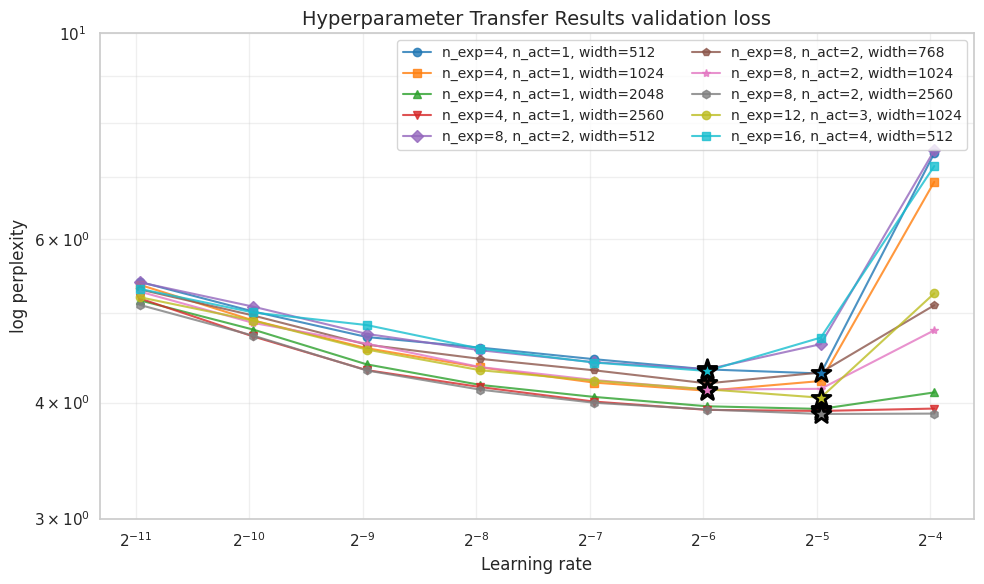

{(4, 512): [(0.0005, np.float64(5.397987365722656)),
  (0.001, np.float64(5.015271663665772)),
  (0.002, np.float64(4.707213401794434)),
  (0.004, np.float64(4.58497953414917)),
  (0.008, np.float64(4.455459117889404)),
  (0.016, np.float64(4.34368371963501)),
  (0.032, np.float64(4.299798965454102)),
  (0.064, np.float64(7.426051616668701))],
 (4, 1024): [(0.0005, np.float64(5.358705997467041)),
  (0.001, np.float64(4.904928684234619)),
  (0.002, np.float64(4.578450202941895)),
  (0.004, np.float64(4.365713119506836)),
  (0.008, np.float64(4.204164028167725)),
  (0.016, np.float64(4.119670391082764)),
  (0.032, np.float64(4.220244884490967)),
  (0.064, np.float64(6.918356418609619))],
 (4, 2048): [(0.0005, np.float64(5.15606164932251)),
  (0.001, np.float64(4.794787883758545)),
  (0.002, np.float64(4.398253917694092)),
  (0.004, np.float64(4.179684638977051)),
  (0.008, np.float64(4.057272911071777)),
  (0.016, np.float64(3.963801622390747)),
  (0.032, np.float64(3.937549114227295)),


In [5]:
plot_results(results_val, title = "validation loss")

In [55]:
def get_filenames_in_dir(directory_path):
      try:
          filenames = os.listdir(directory_path)
          return filenames
      except FileNotFoundError:
          print(f"Directory not found: {directory_path}")
          return []

def parse_validation_loss(log_file_path):
    result = {}
    pattern = r'Validation - step (\d+): val loss ([\d.]+)'

    try:
        with open(log_file_path, 'r') as f:
            for line in f:
                match = re.search(pattern, line)
                if match:
                    step = int(match.group(1))
                    loss = float(match.group(2))
                    result[step] = loss
    except FileNotFoundError:
        print(f"Error: File {log_file_path} not found")
        return {}
    except Exception as e:
        print(f"Error reading file: {e}")
        return {}
print(parse_validation_loss("/home/ubuntu/MuP_MOE/std_out/mutransfer_lr_cccc/20250930_041850/stdout/job_0006_gpu6_w512_exp4_lr2.00e-03_seed3.log"))

None


In [56]:
import re

def parse_validation_loss(log_file_path):
    result = {}
    pattern = r'Validation - step (\d+): val loss ([\d.]+)'

    try:
        with open(log_file_path, 'r') as f:
            for line in f:
                match = re.search(pattern, line)
                if match:
                    step = int(match.group(1))
                    loss = float(match.group(2))
                    result[step] = loss
    except FileNotFoundError:
        print(f"Error: File {log_file_path} not found")
        return {}
    except Exception as e:
        print(f"Error reading file: {e}")
        return {}
    return result

print(parse_validation_loss("/home/ubuntu/MuP_MOE/std_out/mutransfer_lr_cccc/20250930_041850/stdout/job_0006_gpu6_w512_exp4_lr2.00e-03_seed3.log"))

{1: 10.8439, 1001: 5.4033, 2001: 4.6293, 3001: 4.3399, 4001: 4.1837, 5001: 4.0975, 6001: 4.0193, 7001: 3.965, 8001: 3.9159, 9001: 3.8888, 10001: 3.884}


In [57]:
result_complete = {}
for file_name in get_filenames_in_dir("/home/ubuntu/MuP_MOE/std_out/mutransfer_lr_cccc/"+time+"/stdout"):
    file_pwd = "/home/ubuntu/MuP_MOE/std_out/mutransfer_lr_cccc/"+time+"/stdout/"+file_name
    if os.path.exists(file_pwd):
        print(file_pwd)
        pattern = r'job_\d+_gpu\d+_w(\d+)_exp(\d+)_lr([\d.e\-+]+)_seed(\d+)\.log'
        match = re.match(pattern, file_name)
        if not match:
            print(f"File {file_name} does not match the expected pattern")
        params = {
                'width': int(match.group(1)),
                'num_exp': int(match.group(2)),
                'lr': float(match.group(3)),
                'seed': int(match.group(4))
                }
        loss_dict = parse_validation_loss(file_pwd)
        width, num_exp, num_act, seed, lr = params['width'], params['num_exp'], params['num_exp']//4 , params['seed'], params['lr']
        result_complete[(width, num_exp, num_act, seed, lr)] = loss_dict
        print(f"job found, width {width}, num_exp {num_exp}, num_act {num_act}, seed {seed}, lr {lr}, loss_dict {loss_dict}")
    else:
        print(f"File {file_pwd} does not exist, check your path")

/home/ubuntu/MuP_MOE/std_out/mutransfer_lr_cccc/20250930_041850/stdout/job_0006_gpu6_w512_exp4_lr2.00e-03_seed3.log
job found, width 512, num_exp 4, num_act 1, seed 3, lr 0.002, loss_dict {1: 10.8439, 1001: 5.4033, 2001: 4.6293, 3001: 4.3399, 4001: 4.1837, 5001: 4.0975, 6001: 4.0193, 7001: 3.965, 8001: 3.9159, 9001: 3.8888, 10001: 3.884}
/home/ubuntu/MuP_MOE/std_out/mutransfer_lr_cccc/20250930_041850/stdout/job_0004_gpu4_w512_exp4_lr2.00e-03_seed1.log
job found, width 512, num_exp 4, num_act 1, seed 1, lr 0.002, loss_dict {1: 10.8539, 1001: 5.4032, 2001: 4.7307, 3001: 4.502, 4001: 4.3643, 5001: 4.27, 6001: 4.1854, 7001: 4.1179, 8001: 4.0573, 9001: 4.0245, 10001: 4.0108}
/home/ubuntu/MuP_MOE/std_out/mutransfer_lr_cccc/20250930_041850/stdout/job_0014_gpu6_w512_exp4_lr8.00e-03_seed3.log
job found, width 512, num_exp 4, num_act 1, seed 3, lr 0.008, loss_dict {1: 10.8439, 1001: 4.8717, 2001: 4.3258, 3001: 4.1572, 4001: 4.0597}
/home/ubuntu/MuP_MOE/std_out/mutransfer_lr_cccc/20250930_041850/

In [58]:
def plot_results_per_seed(result, title=""):
    """
    Plot separate curves per seed (no averaging on the plot),
    but keep the return value identical to the original function:
      returns a dict keyed by (n_exp, width) -> list of (lr, avg_mse across seeds)
    """
    plt.figure(figsize=(10, 6))

    # 1) Reorganize: group by (n_exp, width) then by seed
    config_seed_results = {}  # {(n_exp, width): {seed: [(lr, mse), ...], ...}, ...}
    for (width, num_exp, num_act, seed, lr), mse in result.items():
        config = (num_exp, width)
        if config not in config_seed_results:
            config_seed_results[config] = {}
        if seed not in config_seed_results[config]:
            config_seed_results[config][seed] = []
        config_seed_results[config][seed].append((lr, mse))

    # 2) Compute the same "averaged across seeds" structure for return + summary (unchanged format)
    averaged_results = {}  # {(n_exp, width): [(lr, avg_mse), ...]}
    for config, seed_dict in config_seed_results.items():
        lr_to_mses = {}
        for seed, pts in seed_dict.items():
            for lr, mse in pts:
                if lr not in lr_to_mses:
                    lr_to_mses[lr] = []
                lr_to_mses[lr].append(mse)
        averaged_pts = []
        for lr in sorted(lr_to_mses.keys()):
            # Keep behavior close to original: use np.mean, NaNs will propagate and be filtered later
            avg_mse = np.mean(lr_to_mses[lr])
            averaged_pts.append((lr, avg_mse))
        averaged_results[config] = averaged_pts

    # 3) Count total experiments (unchanged)
    total_experiments = len(result)
    print(f"Total experiments: {total_experiments}")

    # 4) Print summary by configuration using the averaged results (unchanged)
    print("\nResults by configuration:")
    for (n_exp, width), pts in sorted(averaged_results.items()):
        valid_pts = [(lr, mse) for lr, mse in pts if not math.isnan(mse)]
        print(f"  n={n_exp}, width={width}: {len(valid_pts)} valid lr points")
        if valid_pts:
            best_lr, best_mse = min(valid_pts, key=lambda x: x[1])
            print(f"    Best: lr={best_lr:.3e}, MSE={best_mse:.6f}")

    # 5) Plot: a separate curve for each seed within each configuration
    #    Use a palette/marker cycle per configuration so same (n_exp,width) but different seeds show distinct curves
    base_markers = ['o', 's', '^', 'v', 'D', 'p', '*', 'h', 'X', 'P', '>', '<']
    for idx_cfg, ((n_exp, width), seed_dict) in enumerate(sorted(config_seed_results.items())):
        seeds_sorted = sorted(seed_dict.keys())
        # Create a color cycle sized to the number of seeds for this configuration
        # (tab20 gives up to 20 distinct colors; will cycle if more)
        colors = plt.cm.tab20(np.linspace(0, 1, max(2, min(20, len(seeds_sorted)))))
        for j, seed in enumerate(seeds_sorted):
            pts = seed_dict[seed]

            # Sort by lr and filter NaNs for plotting; also collapse duplicate lr within the same seed by averaging
            lr_to_mses_seed = {}
            for lr, mse in pts:
                if lr not in lr_to_mses_seed:
                    lr_to_mses_seed[lr] = []
                lr_to_mses_seed[lr].append(mse)
            pts_seed = []
            for lr in sorted(lr_to_mses_seed.keys()):
                mean_mse = np.mean(lr_to_mses_seed[lr])
                pts_seed.append((lr, mean_mse))

            if not pts_seed:
                continue

            lrs_plot, mses = zip(*pts_seed)
            valid = [(lr, mse) for lr, mse in zip(lrs_plot, mses) if not math.isnan(mse)]
            if not valid:
                continue

            valid_lrs, valid_mses = zip(*valid)
            color = colors[j % len(colors)]
            marker = base_markers[j % len(base_markers)]
            num_act_est = int(n_exp // 4)  # keep the same display logic as original

            plt.plot(
                valid_lrs, valid_mses,
                marker=marker, color=color, linewidth=1.5, markersize=6, alpha=0.9,
                label=f'n_exp={n_exp}, n_act={num_act_est}, width={width}, seed={seed}'
            )

            # Mark best point for this seed
            best_idx = int(np.argmin(valid_mses))
            plt.scatter(
                valid_lrs[best_idx], valid_mses[best_idx],
                s=200, color=color, marker='*', edgecolor='black', linewidth=2, zorder=10
            )

    # 6) Axes, labels, legend, styling (unchanged)
    plt.xscale('log', base=2)
    plt.yscale('log')
    plt.xlabel(r'Learning rate', fontsize=12)
    plt.ylabel('log perplexity', fontsize=12)
    plt.title(f'Hyperparameter Transfer Results ' + title, fontsize=14)
    plt.legend(fontsize=10, loc='best', ncol=2)
    plt.grid(True, alpha=0.3, which='both')
    plt.tight_layout()

    # 7) Save plot (unchanged path/name pattern)
    plot_dir = "plots"
    os.makedirs(plot_dir, exist_ok=True)
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    plot_name = os.path.join(plot_dir, f"hp_transfer_plot_{timestamp}.png")
    plt.savefig(plot_name, dpi=150, bbox_inches='tight')
    print(f"\nPlot saved as: {plot_name}")

    plt.show()

    # Return value kept identical to original function (dict of averaged points per (n_exp, width))
    return averaged_results


Total experiments: 16

Results by configuration:
  n=4, width=512: 4 valid lr points
    Best: lr=8.000e-03, MSE=4.884375

Plot saved as: plots/hp_transfer_plot_20250930_150528.png


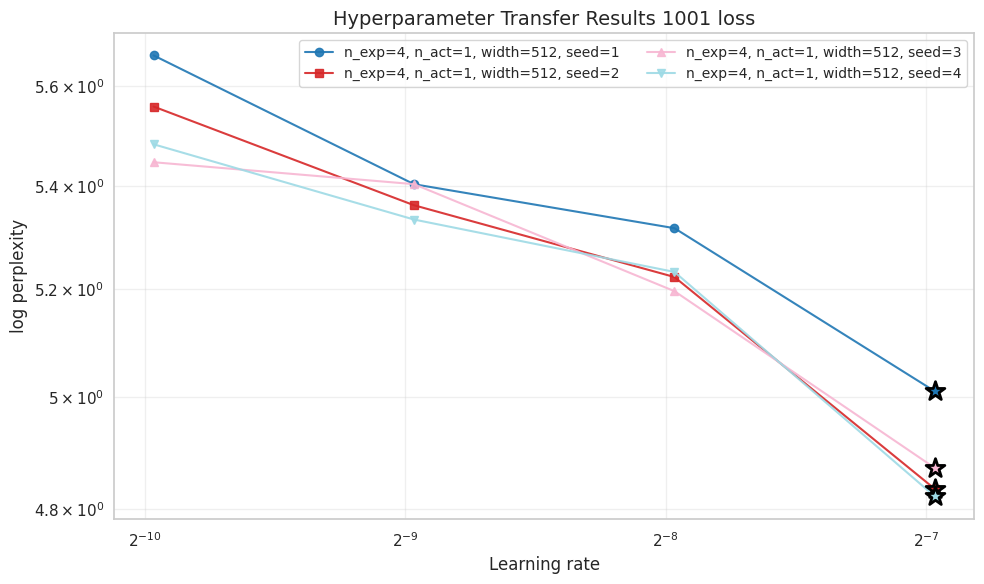

{(4, 512): [(0.001, np.float64(5.537725)),
  (0.002, np.float64(5.3755999999999995)),
  (0.004, np.float64(5.242475)),
  (0.008, np.float64(4.884375))]}

In [59]:
result_1001 = {}
for width, num_exp, _ in wid_exp:
    for i in range(len(lrs)):
        for seed in seeds:
            num_act = int(num_exp // 4)
            for seed in seeds:
                try:
                    result_1001[(width, num_exp, num_act, seed, lrs[i])] = result_complete[(width, num_exp, num_act, seed, lrs[i])][1001]
                except:
                    print(f"never reached 1001 for width {width}, num_exp {num_exp}, num_act {num_act}, seed {seed}, lr {lrs[i]}")
plot_results_per_seed(result_1001, title = "1001 loss")


Total experiments: 16

Results by configuration:
  n=4, width=512: 4 valid lr points
    Best: lr=8.000e-03, MSE=4.359225

Plot saved as: plots/hp_transfer_plot_20250930_150528.png


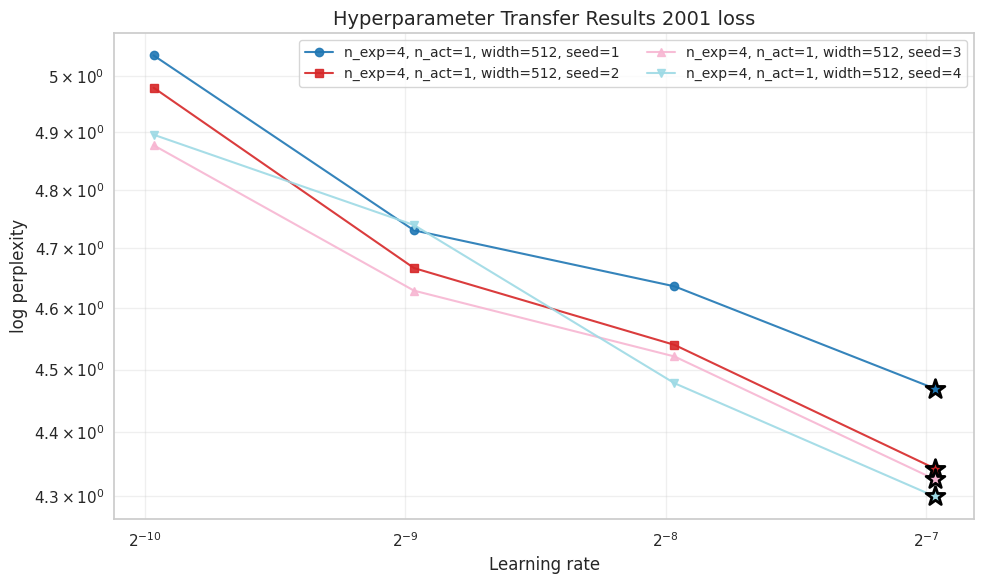

{(4, 512): [(0.001, np.float64(4.9477)),
  (0.002, np.float64(4.691675)),
  (0.004, np.float64(4.543875)),
  (0.008, np.float64(4.3592249999999995))]}

In [60]:
result_2001 = {}
for width, num_exp, _ in wid_exp:
    for i in range(len(lrs)):
        for seed in seeds:
            num_act = int(num_exp // 4)
            for seed in seeds:
                try:
                    result_2001[(width, num_exp, num_act, seed, lrs[i])] = result_complete[(width, num_exp, num_act, seed, lrs[i])][2001]
                except:
                    print(f"never reached 2001 for width {width}, num_exp {num_exp}, num_act {num_act}, seed {seed}, lr {lrs[i]}")
plot_results_per_seed(result_2001, title = "2001 loss")

never reached 5001 for width 512, num_exp 4, num_act 1, seed 3, lr 0.008
never reached 5001 for width 512, num_exp 4, num_act 1, seed 4, lr 0.008
never reached 5001 for width 512, num_exp 4, num_act 1, seed 3, lr 0.008
never reached 5001 for width 512, num_exp 4, num_act 1, seed 4, lr 0.008
never reached 5001 for width 512, num_exp 4, num_act 1, seed 3, lr 0.008
never reached 5001 for width 512, num_exp 4, num_act 1, seed 4, lr 0.008
never reached 5001 for width 512, num_exp 4, num_act 1, seed 3, lr 0.008
never reached 5001 for width 512, num_exp 4, num_act 1, seed 4, lr 0.008
Total experiments: 14

Results by configuration:
  n=4, width=512: 4 valid lr points
    Best: lr=8.000e-03, MSE=4.041800

Plot saved as: plots/hp_transfer_plot_20250930_150529.png


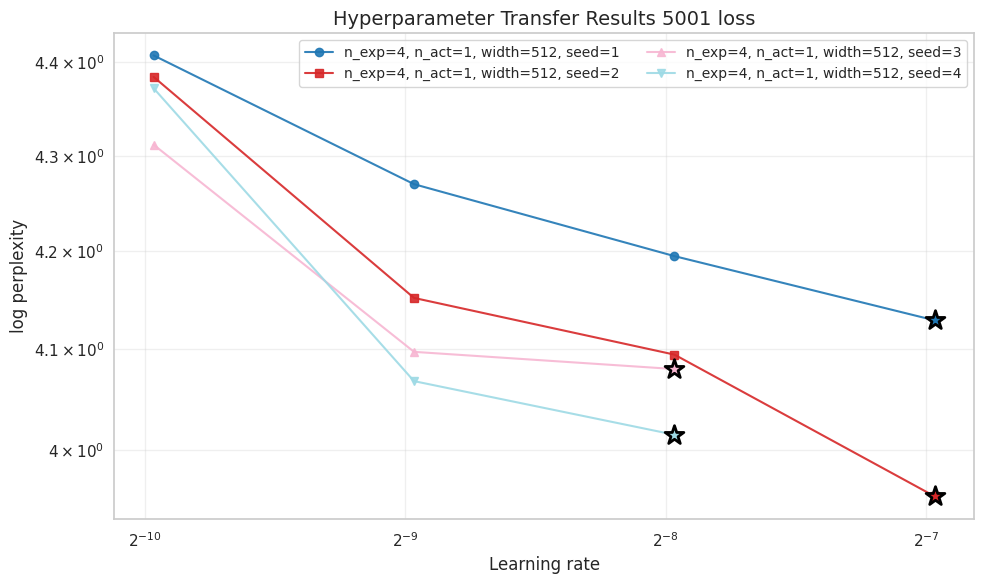

{(4, 512): [(0.001, np.float64(4.368824999999999)),
  (0.002, np.float64(4.14695)),
  (0.004, np.float64(4.0962)),
  (0.008, np.float64(4.0418))]}

In [61]:
result_5001 = {}
for width, num_exp, _ in wid_exp:
    for i in range(len(lrs)):
        for seed in seeds:
            num_act = int(num_exp // 4)
            for seed in seeds:
                try:
                    result_5001[(width, num_exp, num_act, seed, lrs[i])] = result_complete[(width, num_exp, num_act, seed, lrs[i])][5001]
                except:
                    print(f"never reached 5001 for width {width}, num_exp {num_exp}, num_act {num_act}, seed {seed}, lr {lrs[i]}")
plot_results_per_seed(result_5001, title = "5001 loss")

never reached 8001 for width 512, num_exp 4, num_act 1, seed 3, lr 0.004
never reached 8001 for width 512, num_exp 4, num_act 1, seed 4, lr 0.004
never reached 8001 for width 512, num_exp 4, num_act 1, seed 3, lr 0.004
never reached 8001 for width 512, num_exp 4, num_act 1, seed 4, lr 0.004
never reached 8001 for width 512, num_exp 4, num_act 1, seed 3, lr 0.004
never reached 8001 for width 512, num_exp 4, num_act 1, seed 4, lr 0.004
never reached 8001 for width 512, num_exp 4, num_act 1, seed 3, lr 0.004
never reached 8001 for width 512, num_exp 4, num_act 1, seed 4, lr 0.004
never reached 8001 for width 512, num_exp 4, num_act 1, seed 2, lr 0.008
never reached 8001 for width 512, num_exp 4, num_act 1, seed 3, lr 0.008
never reached 8001 for width 512, num_exp 4, num_act 1, seed 4, lr 0.008
never reached 8001 for width 512, num_exp 4, num_act 1, seed 2, lr 0.008
never reached 8001 for width 512, num_exp 4, num_act 1, seed 3, lr 0.008
never reached 8001 for width 512, num_exp 4, num_ac

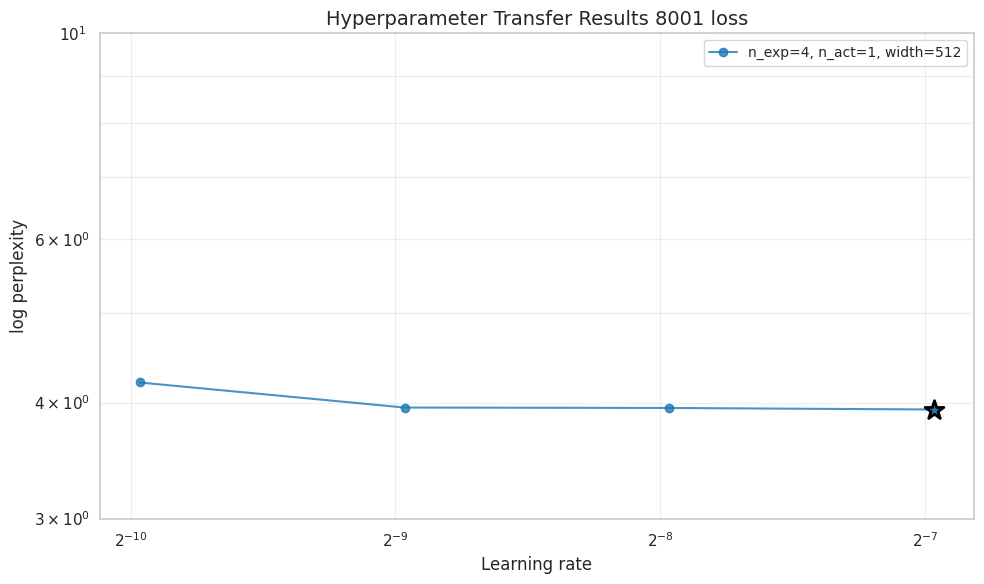

{(4, 512): [(0.001, np.float64(4.204725)),
  (0.002, np.float64(3.951375)),
  (0.004, np.float64(3.9471499999999997)),
  (0.008, np.float64(3.9322))]}

In [62]:
result_8001 = {}
for width, num_exp, _ in wid_exp:
    for i in range(len(lrs)):
        for seed in seeds:
            num_act = int(num_exp // 4)
            for seed in seeds:
                try:
                    result_8001[(width, num_exp, num_act, seed, lrs[i])] = result_complete[(width, num_exp, num_act, seed, lrs[i])][8001]
                except:
                    print(f"never reached 8001 for width {width}, num_exp {num_exp}, num_act {num_act}, seed {seed}, lr {lrs[i]}")
plot_results(result_8001, title = "8001 loss")

In [63]:
import re

def parse_validation_loss(log_file_path):
    result = {}
    pattern = r'Validation - step (\d+): val loss ([\d.]+)'

    try:
        with open(log_file_path, 'r') as f:
            for line in f:
                match = re.search(pattern, line)
                if match:
                    step = int(match.group(1))
                    loss = float(match.group(2))
                    result[step] = loss
    except FileNotFoundError:
        print(f"Error: File {log_file_path} not found")
        return {}
    except Exception as e:
        print(f"Error reading file: {e}")
        return {}
    return result

result = parse_validation_loss("/home/ubuntu/MuP_MOE/std_out/mutransfer_lr_cccc/20250930_041850/stdout/job_0006_gpu6_w512_exp4_lr2.00e-03_seed3.log")
print(result)

{1: 10.8439, 1001: 5.4033, 2001: 4.6293, 3001: 4.3399, 4001: 4.1837, 5001: 4.0975, 6001: 4.0193, 7001: 3.965, 8001: 3.9159, 9001: 3.8888, 10001: 3.884}
